# Task Anchoring Catalogue — All Brain Regions

## What is task anchoring?

On each trial of the virtual-reality task, a cell's spatial tuning curve is
linearised and its dominant spectral frequency is extracted.  A cell is
**anchored** on a given trial if that frequency is a harmonic of 1/track_length
(i.e. 1/200, 2/200, cm^-1) — meaning its firing is spatially periodic and
locked to the track structure rather than to some other rhythm.

## What this notebook does

For every recorded session it:

1. **Computes per-trial anchoring labels** for all cells across all brain regions using
   `spectral_analysis` + `get_kmeans_spatial_labels`.  The first and last 8 trials
   are masked (NaN) because the spectrogram window cannot be centred on edge trials.

2. **Identifies the dominant switching pattern** with PCA on the full cell x trial
   smoothed-label matrix.  PC1 captures the strongest co-modulation across cells
   *without* pre-averaging over the population — a minority subpopulation that
   switches coherently will dominate PC1 even if most cells do not participate.

3. **Characterises each cell** by its Pearson correlation with the PC1 trial score.
   High positive correlation = the cell co-modulates with the dominant pattern.
   Near-zero = does not participate.  Negative = anti-correlated.

4. **Produces a figure per session** (3 columns x 2 rows):
   - *Top row, right*: PC1 trial score (normalised to [0,1]).  Title reports
     PC1 variance explained and the fraction of agreeing cells (r > 0.3).
   - *Bottom row*: region colour strip (MEC=green, VIS=purple) | PC1 correlation
     strip (red=agrees, white=neutral, blue=anti) | anchoring raster sorted by
     correlation descending (most agreeing cells at top).

5. **Cross-session summary**: ranks sessions by `agree_frac` — the fraction of
   cells with PC1 correlation > 0.3.  Sessions with high PC1 variance explained
   AND many agreeing cells have the clearest switching structure.

## Key parameters

| Parameter | Value | Meaning |
|---|---|---|
| `bs` | 2 cm | spatial bin size |
| `tl` | 200 cm | track length |
| `TARGET_FREQS` | 1-5 x bs/tl | harmonics tested for anchoring |
| `edge` | 8 trials | masked at each end (no valid spectral window) |
| Agreement threshold | r > 0.3 | cell counted as agreeing with PC1 |

## Cell colours

- **Purple** `#9d5391` — trial anchored
- **Light pink** `#e7d7e8` — trial non-anchored
- **White** — masked (edge trials or missing data)
- **Green strip** — MEC cell (ENTm region)
- **Purple/violet strip** — VIS cell

In [9]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import pynapple as nap
from spatial_manifolds.detect_grids import compute_vr_tcs, get_kmeans_spatial_labels
from spatial_manifolds.toroidal import spectral_analysis

In [10]:
SOURCE_PATH   = '/Users/harryclark/Downloads/COHORT12/'
CELLS_CSV     = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv'
CATALOGUE_DIR = Path('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/catalogue')
CATALOGUE_DIR.mkdir(exist_ok=True)

bs  = 2      # cm per spatial bin
tl  = 200    # VR track length (cm)
PRINCIPAL_MAX_FR = 10.0   # Hz

TARGET_FREQS = np.arange(1, 6) * bs / tl   # [0.01, 0.02, 0.03, 0.04, 0.05] cm^-1

COLOR_ANCHOR     = '#9d5391'
COLOR_NON_ANCHOR = '#e7d7e8'

In [11]:
def _prep(df):
    df['mouse']      = df['mouse'].astype(int)
    df['day']        = df['day'].astype(int)
    df['cluster_id'] = df['cluster_id'].astype(int)
    return df

df_all = _prep(pd.read_csv(CELLS_CSV))

all_sessions = sorted(set(map(tuple, df_all[['mouse','day']].values.tolist())))
print(f'Sessions: {len(all_sessions)}  Total cells: {len(df_all)}')
print('\nCells per brain region (top 15):')
print(df_all['brain_region'].value_counts().head(15).to_string())

Sessions: 79  Total cells: 11115

Cells per brain region (top 15):
brain_region
ENTm3      2445
ENTm5      1707
ENTm2      1463
ENTm1       760
PAR         685
ENTm6       533
VISp6a      522
VISpl5      423
PRE         409
SUB         330
VISp5       288
VISp4       183
VISl5       167
VISpl6a     165
VISl2/3     128


In [12]:
def compute_anchoring_labels(cid, tcs):
    tc = tcs.get(cid)
    if tc is None or len(tc) == 0:
        return None
    try:
        _DUMMY = cid + 100000
        results     = spectral_analysis({cid: tc, _DUMMY: tc}, tl, bs)
        fvalid      = results[5]
        freq_idx    = [int(np.argmin(np.abs(fvalid - f))) for f in TARGET_FREQS]
        lbl_per_win = np.isin(np.argmax(results[3][0], axis=0), freq_idx).astype(int)
        labels = get_kmeans_spatial_labels(tc, lbl_per_win, bs=bs, tl=tl).astype(float)
        edge = int(1600 / (2 * (tl / bs)))   # 8 trials — no valid spectral window near edges
        labels[:edge]  = np.nan
        labels[-edge:] = np.nan
        return labels
    except Exception:
        return None


def _pca_cell_agreement(labels, n_pcs=5):
    # PCA on smoothed cell x trial matrix.
    # Returns PC1 trial score, each cell's Pearson correlation with PC1,
    # and enrichment over chance for each of the first n_pcs components.
    # Enrichment = var_expl[k] * n_cells; chance baseline = 1.0.
    # No pre-averaging: minority subpopulations dominate PC1 if they switch coherently.
    from sklearn.decomposition import PCA
    if not labels:
        raise ValueError('_pca_cell_agreement received an empty label list')
    n_cells    = len(labels)
    max_trials = max(len(l) for l in labels)

    smoothed = np.full((n_cells, max_trials), 0.5)
    for i, lab in enumerate(labels):
        s = pd.Series(lab).rolling(5, center=True, min_periods=1).mean()
        smoothed[i, :len(lab)] = s.fillna(0.5).values

    k           = min(n_pcs, n_cells, max_trials)
    pca         = PCA(n_components=k)
    scores      = pca.fit_transform(smoothed.T)   # (max_trials, k)
    trial_score = scores[:, 0]
    # enrichment[i] = var_expl[i] * n_cells  (=1.0 at chance for all i)
    enrichment  = pca.explained_variance_ratio_ * n_cells
    var_expl    = float(pca.explained_variance_ratio_[0])

    cell_corr = np.array([
        np.corrcoef(smoothed[i], trial_score)[0, 1]
        for i in range(n_cells)
    ])

    # Orient: majority of cells correlate positively
    if (cell_corr > 0).sum() < n_cells / 2:
        trial_score = -trial_score
        cell_corr   = -cell_corr

    return trial_score, cell_corr, var_expl, enrichment


def _cell_autocorr(lab, max_lag=20):
    # Autocorrelation of binary anchoring sequence at lags 1..max_lag.
    # NaN (edge-masked) trials are dropped before computation.
    s = pd.Series(lab).dropna()
    if len(s) < max_lag + 5:
        return np.full(max_lag, np.nan)
    return np.array([s.autocorr(lag=k) for k in range(1, max_lag + 1)])

## Example: Mouse 26 Day 18

All MEC + VIS cells combined. Cells are sorted top-to-bottom by their Pearson
correlation with PC1 (most agreeing first). The side strip shows the correlation
value (red = agrees, white = neutral, blue = anti-correlated).

M26D18: 89 cells — ENTm2=30  VISpl5=30  ENTm3=12  ENTm1=8  VISp5=6  VISp2/3=3
PC1=46.1x  PC2=4.2x  PC3=3.8x  PC4=2.7x  PC5=2.4x  |  dominance(PC1/PC2)=11.0
agreeing (r>0.3): 68/89  (76%)


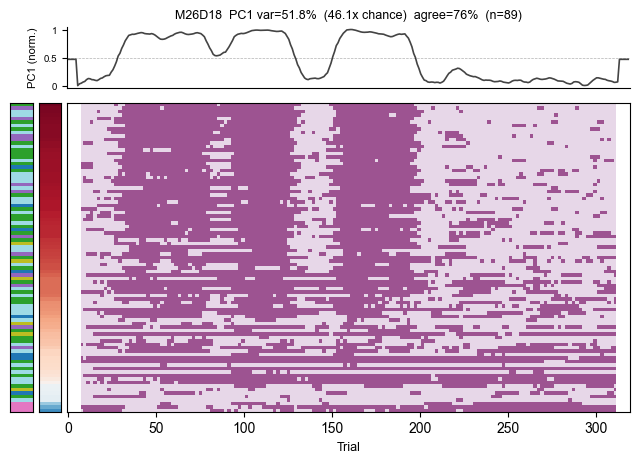

In [13]:
from IPython.display import display as _disp

EX_MOUSE, EX_DAY = 26, 18

tcs_ex, _, _, last_ephys_bin_ex, beh_ex, clusters_ex =     compute_vr_tcs(EX_MOUSE, EX_DAY, source_path=SOURCE_PATH)

_sess_ex = df_all[(df_all['mouse'] == EX_MOUSE) & (df_all['day'] == EX_DAY)]
ex_labels, ex_scx, ex_region = [], [], []
for _, row in _sess_ex.iterrows():
    lab = compute_anchoring_labels(int(row['cluster_id']), tcs_ex)
    if lab is not None:
        ex_labels.append(lab)
        ex_scx.append(float(row['SC_x']) if pd.notna(row['SC_x']) else np.nan)
        ex_region.append(str(row.get('brain_region', 'unknown')))

n_cells = len(ex_labels)
reg_counts = pd.Series(ex_region).value_counts().to_dict()
print(f'M{EX_MOUSE}D{EX_DAY}: {n_cells} cells — ' +
      '  '.join(f'{r}={c}' for r, c in reg_counts.items()))

# PCA: find cells that agree with the dominant switching pattern
# cell_corr[i] = Pearson r between cell i's smoothed labels and PC1.
# No pre-averaging — a switching subpopulation will dominate PC1 even if
# most cells do not participate.
trial_score, cell_corr, var_expl, enrichment = _pca_cell_agreement(ex_labels)
max_trials      = len(trial_score)
agree_frac      = float((cell_corr > 0.3).sum() / n_cells)
pc1_enrichment  = float(enrichment[0])
pc1_dominance   = float(enrichment[0] / enrichment[1]) if len(enrichment) > 1 else float('nan')
enrich_str      = '  '.join(f'PC{i+1}={e:.1f}x' for i, e in enumerate(enrichment))
print(f'{enrich_str}  |  dominance(PC1/PC2)={pc1_dominance:.1f}')
print(f'agreeing (r>0.3): {int((cell_corr > 0.3).sum())}/{n_cells}  ({agree_frac:.0%})')

# Sort cells by PC1 correlation descending (most agreeing at top)
sort_order    = np.argsort(-cell_corr).tolist()
mat_disp_all  = np.full((n_cells, max_trials), np.nan)
for i, lab in enumerate(ex_labels):
    mat_disp_all[i, :len(lab)] = lab
mat_plot      = mat_disp_all[sort_order]
region_sorted = [ex_region[i] for i in sort_order]
corr_sorted   = cell_corr[sort_order]

# Figure: 3 col x 2 row
# Row 0: [blank][blank][PC1 trial score]
# Row 1: [region strip][PC1 correlation strip][anchoring raster]
fig_ex, axes_ex = plt.subplots(
    2, 3, figsize=(8, 5),
    gridspec_kw=dict(height_ratios=[1, 5],
                     width_ratios=[0.04, 0.04, 1],
                     hspace=0.08, wspace=0.03)
)
axes_ex[0, 0].axis('off'); axes_ex[0, 1].axis('off')

ax_maps  = axes_ex[0, 2]
trial_ax = np.arange(max_trials)
ts_norm  = (trial_score - trial_score.min()) / (trial_score.max() - trial_score.min() + 1e-8)
ax_maps.plot(trial_ax, ts_norm, color='#444444', lw=1.2)
ax_maps.axhline(0.5, color='k', lw=0.5, ls='--', alpha=0.3)
ax_maps.set_xlim(0, max_trials); ax_maps.set_ylim(-0.05, 1.05)
ax_maps.set_yticks([0, 0.5, 1]); ax_maps.set_yticklabels(['0', '0.5', '1'], fontsize=7)
ax_maps.set_ylabel('PC1 (norm.)', fontsize=8); ax_maps.set_xticks([])
ax_maps.tick_params(labelsize=7)
ax_maps.spines['top'].set_visible(False); ax_maps.spines['right'].set_visible(False)
ax_maps.set_title(
    f'M{EX_MOUSE}D{EX_DAY}  PC1 var={var_expl:.1%}  ({pc1_enrichment:.1f}x chance)  agree={agree_frac:.0%}  (n={n_cells})',
    fontsize=9
)

ax_reg  = axes_ex[1, 0]; ax_cl = axes_ex[1, 1]; ax_rast = axes_ex[1, 2]

_unique_regs_ex = sorted(set(region_sorted))
_reg_to_idx_ex  = {r: i for i, r in enumerate(_unique_regs_ex)}
reg_vals = np.array([_reg_to_idx_ex[r] for r in region_sorted])[:, np.newaxis]
ax_reg.imshow(reg_vals, aspect='auto',
              cmap=plt.cm.get_cmap('tab20', len(_unique_regs_ex)),
              vmin=-0.5, vmax=len(_unique_regs_ex) - 0.5,
              interpolation='nearest', origin='upper')
ax_reg.set_xticks([]); ax_reg.set_yticks([])

# Correlation strip: red = agrees with PC1, white = no correlation, blue = anti
ax_cl.imshow(corr_sorted[:, np.newaxis], aspect='auto',
             cmap='RdBu_r', vmin=-1, vmax=1,
             interpolation='nearest', origin='upper')
ax_cl.set_xticks([]); ax_cl.set_yticks([])

plot_mat_ex = np.where(np.isnan(mat_plot), 2.0, mat_plot)
cmap_ex     = ListedColormap([COLOR_NON_ANCHOR, COLOR_ANCHOR, 'white'])
norm_ex     = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_ex.N)
ax_rast.imshow(plot_mat_ex, aspect='auto', cmap=cmap_ex, norm=norm_ex,
               interpolation='nearest', origin='upper')
ax_rast.set_xlabel('Trial', fontsize=9); ax_rast.set_yticks([])

_disp(fig_ex)
plt.close(fig_ex)

In [14]:
import matplotlib; matplotlib.use('Agg')

switching_stats = []   # one dict per session
cell_rows       = []   # one dict per cell across all sessions
acf_data        = []   # full autocorrelogram per cell (in-memory only, not saved to CSV)


def _session_figure(mouse, day, labels, regions):
    n_cells = len(labels)

    trial_score, cell_corr, var_expl, enrichment = _pca_cell_agreement(labels)
    max_trials     = len(trial_score)
    agree_frac     = float((cell_corr > 0.3).sum() / n_cells)
    pc1_enrichment = float(enrichment[0])
    pc1_dominance  = float(enrichment[0] / enrichment[1]) if len(enrichment) > 1 else np.nan

    sort_order    = np.argsort(-cell_corr).tolist()
    mat_disp      = np.full((n_cells, max_trials), np.nan)
    for i, lab in enumerate(labels):
        mat_disp[i, :len(lab)] = lab
    mat_plot      = mat_disp[sort_order]
    region_sorted = [regions[i] for i in sort_order]
    corr_sorted   = cell_corr[sort_order]

    fig, axes = plt.subplots(
        2, 3, figsize=(8, 5),
        gridspec_kw=dict(height_ratios=[1, 5],
                         width_ratios=[0.04, 0.04, 1],
                         hspace=0.08, wspace=0.03)
    )
    axes[0, 0].axis('off'); axes[0, 1].axis('off')

    ax_maps  = axes[0, 2]
    trial_ax = np.arange(max_trials)
    ts_norm  = (trial_score - trial_score.min()) / (trial_score.max() - trial_score.min() + 1e-8)
    ax_maps.plot(trial_ax, ts_norm, color='#444444', lw=1.2)
    ax_maps.axhline(0.5, color='k', lw=0.5, ls='--', alpha=0.3)
    ax_maps.set_xlim(0, max_trials); ax_maps.set_ylim(-0.05, 1.05)
    ax_maps.set_yticks([0, 0.5, 1]); ax_maps.set_yticklabels(['0', '0.5', '1'], fontsize=7)
    ax_maps.set_ylabel('PC1 (norm.)', fontsize=8); ax_maps.set_xticks([])
    ax_maps.tick_params(labelsize=7)
    ax_maps.spines['top'].set_visible(False); ax_maps.spines['right'].set_visible(False)
    ax_maps.set_title(
        f'M{mouse}D{day}  PC1 var={var_expl:.1%}  ({pc1_enrichment:.1f}x chance)  agree={agree_frac:.0%}  (n={n_cells})',
        fontsize=9)

    ax_reg = axes[1, 0]; ax_cl = axes[1, 1]; ax_rast = axes[1, 2]
    _unique_regs = sorted(set(region_sorted))
    _reg_to_idx  = {r: i for i, r in enumerate(_unique_regs)}
    reg_vals = np.array([_reg_to_idx[r] for r in region_sorted])[:, np.newaxis]
    ax_reg.imshow(reg_vals, aspect='auto',
                  cmap=plt.cm.get_cmap('tab20', len(_unique_regs)),
                  vmin=-0.5, vmax=len(_unique_regs) - 0.5,
                  interpolation='nearest', origin='upper')
    ax_reg.set_xticks([]); ax_reg.set_yticks([])

    ax_cl.imshow(corr_sorted[:, np.newaxis], aspect='auto',
                 cmap='RdBu_r', vmin=-1, vmax=1,
                 interpolation='nearest', origin='upper')
    ax_cl.set_xticks([]); ax_cl.set_yticks([])

    plot_mat = np.where(np.isnan(mat_plot), 2.0, mat_plot)
    cmap_r   = ListedColormap([COLOR_NON_ANCHOR, COLOR_ANCHOR, 'white'])
    norm_r   = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_r.N)
    ax_rast.imshow(plot_mat, aspect='auto', cmap=cmap_r, norm=norm_r,
                   interpolation='nearest', origin='upper')
    ax_rast.set_xlabel('Trial', fontsize=9); ax_rast.set_yticks([])

    return fig, (n_cells, agree_frac, var_expl, pc1_enrichment, pc1_dominance, enrichment, cell_corr)


for mouse, day in all_sessions:
    try:
        tcs, _, _, _, _, _ = compute_vr_tcs(mouse, day, source_path=SOURCE_PATH)
    except Exception as e:
        print(f'M{mouse}D{day}: skipped (load error): {e}')
        continue

    _sess = df_all[(df_all['mouse']==mouse) & (df_all['day']==day)]

    labels, regions, cids = [], [], []
    for _, row in _sess.iterrows():
        lab = compute_anchoring_labels(int(row['cluster_id']), tcs)
        if lab is not None:
            labels.append(lab)
            regions.append(str(row.get('brain_region', 'unknown')))
            cids.append(int(row['cluster_id']))

    if len(labels) < 4:
        print(f'M{mouse}D{day}: too few cells ({len(labels)}) — skipped')
        continue

    fig, stats = _session_figure(mouse, day, labels, regions)
    n_cells_s, agree_frac_s, var_expl_s, enrich_s, dom_s, enrich_all_s, cell_corr_s = stats
    session_passes = (agree_frac_s > 0.3 and enrich_s > 1.5 and dom_s > 2)
    switching_stats.append({'mouse': mouse, 'day': day,
                             'n_cells': n_cells_s,
                             'agree_frac': agree_frac_s,
                             'var_expl': var_expl_s,
                             'pc1_enrichment': enrich_s,
                             'pc1_dominance': dom_s,
                             'session_passes': session_passes,
                             'enrichment_all': enrich_all_s.tolist()})
    for j, (cid, corr, reg) in enumerate(zip(cids, cell_corr_s, regions)):
        acf   = _cell_autocorr(labels[j])
        lag1  = float(acf[0]) if not np.isnan(acf[0]) else np.nan
        passes = session_passes and bool(corr > 0.3)
        cell_rows.append({
            'mouse': mouse, 'day': day, 'cluster_id': cid, 'region': reg,
            # cell-level
            'cell_corr': round(float(corr), 4),
            'cell_agrees': bool(corr > 0.3),
            'lag1_autocorr': round(lag1, 4) if not np.isnan(lag1) else np.nan,
            # session-level metrics (same for every cell in this session)
            'n_cells': n_cells_s,
            'agree_frac': round(agree_frac_s, 4),
            'var_expl': round(var_expl_s, 4),
            'pc1_enrichment': round(enrich_s, 4),
            'pc1_dominance': round(dom_s, 4),
            # flags
            'session_passes': session_passes,
            'passes_criteria': passes,
        })
        acf_data.append({'passes_criteria': passes, 'acf': acf.tolist()})

    out_path = CATALOGUE_DIR / f'M{mouse}D{day:02d}_anchoring.pdf'
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f'Saved  M{mouse}D{day:02d}  n={n_cells_s}  '
          f'PC1={var_expl_s:.1%}  ({enrich_s:.1f}x)  dom={dom_s:.1f}  agree={agree_frac_s:.0%}  -> {out_path.name}')

print('\nAll sessions complete.')
df_switching = pd.DataFrame(switching_stats).sort_values('agree_frac', ascending=False)
print(df_switching.to_string(index=False))

Saved  M20D14  n=198  PC1=15.7%  (31.1x)  dom=1.5  agree=36%  -> M20D14_anchoring.pdf
Saved  M20D15  n=65  PC1=10.4%  (6.7x)  dom=1.3  agree=23%  -> M20D15_anchoring.pdf
Saved  M20D16  n=209  PC1=7.0%  (14.6x)  dom=1.3  agree=16%  -> M20D16_anchoring.pdf
Saved  M20D17  n=107  PC1=9.4%  (10.0x)  dom=1.3  agree=11%  -> M20D17_anchoring.pdf
Saved  M20D18  n=133  PC1=9.7%  (12.9x)  dom=1.3  agree=16%  -> M20D18_anchoring.pdf
Saved  M20D19  n=108  PC1=8.5%  (9.1x)  dom=1.2  agree=14%  -> M20D19_anchoring.pdf
Saved  M20D20  n=100  PC1=8.9%  (8.9x)  dom=1.2  agree=52%  -> M20D20_anchoring.pdf
Saved  M20D21  n=107  PC1=8.3%  (8.9x)  dom=1.1  agree=16%  -> M20D21_anchoring.pdf
Saved  M20D22  n=66  PC1=11.8%  (7.8x)  dom=1.5  agree=8%  -> M20D22_anchoring.pdf
Saved  M20D23  n=75  PC1=13.0%  (9.8x)  dom=1.5  agree=33%  -> M20D23_anchoring.pdf
Saved  M20D24  n=81  PC1=7.5%  (6.1x)  dom=1.1  agree=12%  -> M20D24_anchoring.pdf
Saved  M20D25  n=35  PC1=22.7%  (7.9x)  dom=2.5  agree=34%  -> M20D25_anc

## Cross-session switching summary

Sessions ranked by `agree_frac` — the fraction of cells with PC1 correlation > 0.3.

**`pc1_enrichment = var_expl * n_cells`** corrects for the fact that PC1 variance
explained has a noise floor of 1/n_cells: for purely random labels each of the n_cells
PCs would explain exactly 1/n_cells of variance, so enrichment = 1.0 is chance.
Enrichment > 2 means PC1 explains at least twice what noise would predict.

Bar colour encodes enrichment (darker = more structured).  Annotated value is
`agree_frac`.  Sessions worth inspecting have both high enrichment (> 2) and high
agree_frac (> 0.3).

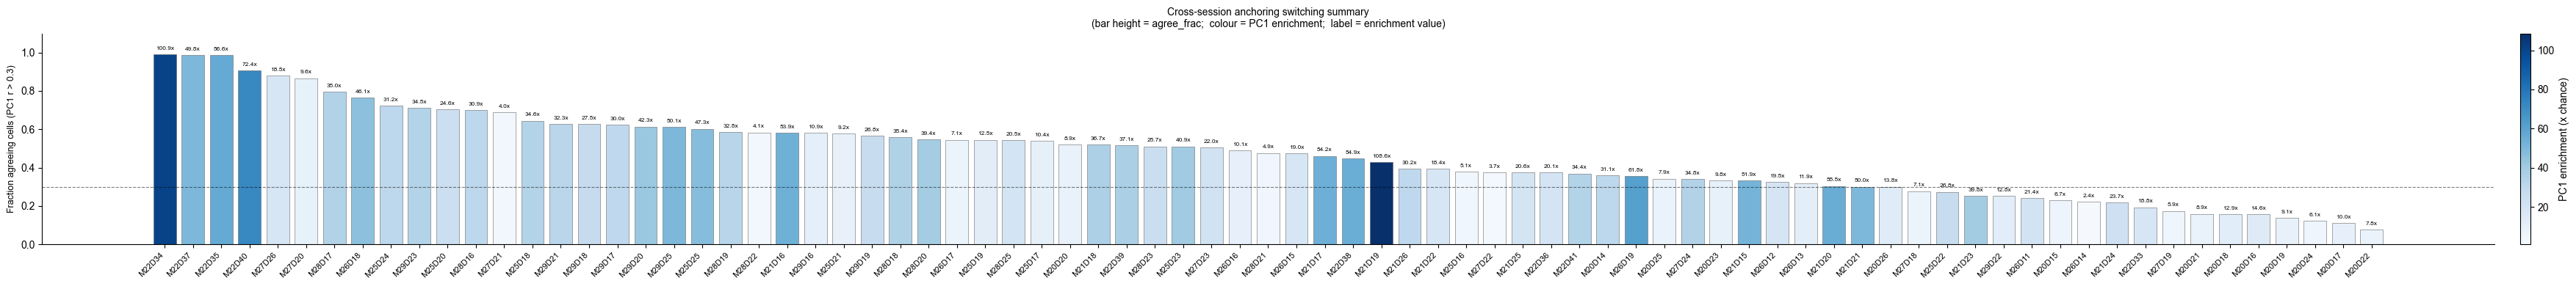

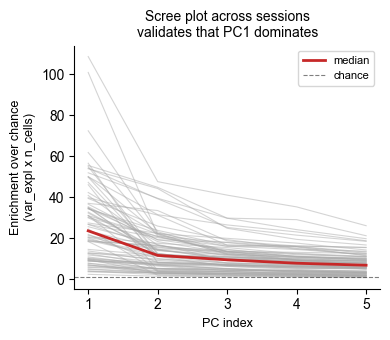

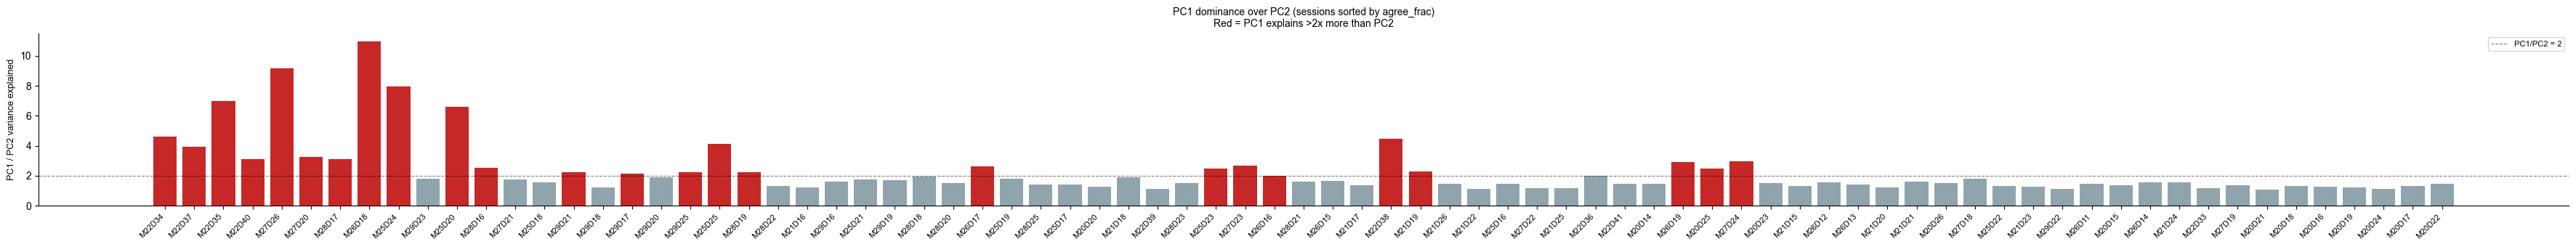


Top sessions (agree_frac > 0.3  AND  pc1_enrichment > 1.5  AND  pc1_dominance > 2):
 mouse  day  n_cells  agree_frac  var_expl  pc1_enrichment  pc1_dominance
    22   34      240    0.991667  0.420214      100.851256       4.631315
    22   37      163    0.987730  0.305708       49.830420       3.923952
    22   35      150    0.986667  0.377364       56.604611       7.007244
    22   40      315    0.907937  0.229894       72.416743       3.121592
    27   26       33    0.878788  0.559181       18.452968       9.155276
    27   20       30    0.866667  0.320794        9.623811       3.247947
    28   17       98    0.795918  0.357218       35.007374       3.126415
    26   18       89    0.764045  0.518224       46.121971      10.966853
    25   24       65    0.723077  0.479264       31.152145       7.957024
    25   20       61    0.704918  0.402507       24.552946       6.599990
    28   16      100    0.700000  0.309034       30.903427       2.506832
    29   21      137    0.6

In [15]:
%matplotlib inline
from IPython.display import display as _disp

if not switching_stats:
    print('No sessions processed — run cell-main first')
else:
    df_sw = pd.DataFrame(switching_stats).sort_values('agree_frac', ascending=False)

    import matplotlib.cm as _cm
    import matplotlib.colors as _mcolors

    fig_sw, ax_sw = plt.subplots(figsize=(max(5, len(df_sw) * 0.45), 4))
    xlabels = [f"M{int(r.mouse)}D{int(r.day)}" for _, r in df_sw.iterrows()]

    # colour bars by pc1_enrichment; cap colormap at 5x for visual range
    enrich_vals = df_sw['pc1_enrichment'].values
    norm_enrich = _mcolors.Normalize(vmin=1, vmax=max(5, enrich_vals.max()))
    cmap_enrich = _cm.get_cmap('Blues')
    bar_colors  = [cmap_enrich(norm_enrich(e)) for e in enrich_vals]

    ax_sw.bar(np.arange(len(df_sw)), df_sw['agree_frac'],
              color=bar_colors, edgecolor='0.4', linewidth=0.4)
    ax_sw.axhline(0.3, color='k', lw=0.8, ls='--', alpha=0.5, label='agree=0.3')
    ax_sw.set_xticks(np.arange(len(df_sw)))
    ax_sw.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_sw.set_ylabel('Fraction agreeing cells (PC1 r > 0.3)', fontsize=9)
    ax_sw.set_ylim(0, 1.1)
    ax_sw.set_title('Cross-session anchoring switching summary\n'
                    '(bar height = agree_frac;  colour = PC1 enrichment;  label = enrichment value)',
                    fontsize=10)
    ax_sw.spines['top'].set_visible(False); ax_sw.spines['right'].set_visible(False)

    sm = _cm.ScalarMappable(cmap=cmap_enrich, norm=norm_enrich)
    sm.set_array([])
    fig_sw.colorbar(sm, ax=ax_sw, label='PC1 enrichment (x chance)', pad=0.01,
                    fraction=0.03)

    for i, (_, r) in enumerate(df_sw.iterrows()):
        ax_sw.text(i, r.agree_frac + 0.02, f'{r.pc1_enrichment:.1f}x',
                   ha='center', va='bottom', fontsize=6)

    fig_sw.tight_layout()
    _disp(fig_sw)
    plt.close(fig_sw)

    # Scree plot: enrichment per PC across sessions
    # x = PC index, y = var_expl * n_cells (enrichment over chance)
    # One grey line per session; bold line = median across sessions.
    # Chance = 1.0 (horizontal dashed line).
    all_enrich = [r['enrichment_all'] for r in switching_stats if 'enrichment_all' in r]
    if all_enrich:
        max_k   = max(len(e) for e in all_enrich)
        enrich_mat = np.full((len(all_enrich), max_k), np.nan)
        for i, e in enumerate(all_enrich):
            enrich_mat[i, :len(e)] = e

        fig_sc, ax_sc = plt.subplots(figsize=(4, 3.5))
        pc_idx = np.arange(1, max_k + 1)
        for row in enrich_mat:
            ax_sc.plot(pc_idx[:len(row[~np.isnan(row)])],
                       row[~np.isnan(row)],
                       color='#aaaaaa', lw=0.8, alpha=0.5)
        med_line = np.nanmedian(enrich_mat, axis=0)
        ax_sc.plot(pc_idx, med_line, color='#c62828', lw=2.0, label='median')
        ax_sc.axhline(1.0, color='k', lw=0.8, ls='--', alpha=0.5, label='chance')
        ax_sc.set_xlabel('PC index', fontsize=9)
        ax_sc.set_ylabel('Enrichment over chance\n(var_expl x n_cells)', fontsize=9)
        ax_sc.set_title('Scree plot across sessions\n'
                        'validates that PC1 dominates', fontsize=10)
        ax_sc.set_xticks(pc_idx)
        ax_sc.legend(fontsize=8)
        ax_sc.spines['top'].set_visible(False); ax_sc.spines['right'].set_visible(False)
        fig_sc.tight_layout()
        _disp(fig_sc)
        plt.close(fig_sc)

    # Dominance bar chart: PC1/PC2 ratio per session, sorted by agree_frac
    # Ratio > 2 (dashed line) means PC1 explains at least 2x more than PC2.
    # n_cells cancels in the ratio so no enrichment correction needed here.
    if 'pc1_dominance' in df_sw.columns:
        fig_dom, ax_dom = plt.subplots(figsize=(max(5, len(df_sw) * 0.45), 3.5))
        dom_vals   = df_sw['pc1_dominance'].values
        dom_colors = ['#c62828' if d > 2 else '#90a4ae' for d in dom_vals]
        ax_dom.bar(np.arange(len(df_sw)), dom_vals, color=dom_colors, edgecolor='none')
        ax_dom.axhline(2, color='k', lw=0.8, ls='--', alpha=0.5, label='PC1/PC2 = 2')
        ax_dom.set_xticks(np.arange(len(df_sw)))
        ax_dom.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
        ax_dom.set_ylabel('PC1 / PC2 variance explained', fontsize=9)
        ax_dom.set_title('PC1 dominance over PC2 (sessions sorted by agree_frac)\n'
                         'Red = PC1 explains >2x more than PC2', fontsize=10)
        ax_dom.legend(fontsize=8)
        ax_dom.spines['top'].set_visible(False); ax_dom.spines['right'].set_visible(False)
        fig_dom.tight_layout()
        _disp(fig_dom)
        plt.close(fig_dom)

    print('\nTop sessions (agree_frac > 0.3  AND  pc1_enrichment > 1.5  AND  pc1_dominance > 2):')
    _top = df_sw[(df_sw['agree_frac'] > 0.3) &
                 (df_sw['pc1_enrichment'] > 1.5) &
                 (df_sw['pc1_dominance'] > 2)]
    if len(_top):
        print(_top[['mouse','day','n_cells','agree_frac','var_expl',
                     'pc1_enrichment','pc1_dominance']].to_string(index=False))
    else:
        print('  (none)')

## Cell inclusion flags

The table below records every cell across every processed session and whether it
passes the combined criteria for use in further analysis.

### Criteria

| Level | Criterion | Rationale |
|---|---|---|
| Session | `agree_frac > 0.3` | At least 30% of cells correlate with PC1 — session has a real population-level switching signal |
| Session | `pc1_enrichment > 1.5` | PC1 explains 50% more variance than chance (1/n_cells) — not pure noise |
| Session | `pc1_dominance > 2` | PC1 explains at least 2x more than PC2 — the structure is effectively 1-dimensional |
| Cell | `cell_corr > 0.3` | Individual cell Pearson r with PC1 — cell participates in the dominant switching pattern |

`passes_criteria = True` requires **all four** conditions to hold.

### What is filtered out

- **Sessions with low agree_frac**: No coherent population switching detected — the anchoring labels are either stable across all trials or switching independently per cell with no shared structure.
- **Sessions with low pc1_enrichment**: PC1 is not meaningfully above the noise floor expected from random binary labels — the variance is spread uniformly across PCs.
- **Sessions with low pc1_dominance**: More than one comparably sized switching pattern is present — the dominant axis is ambiguous and PC1 may not be representative.
- **Cells with low cell_corr**: Even within a passing session, individual cells that do not co-modulate with the dominant switching pattern are excluded — they may be driven by a different mechanism or simply be noisy.

Saved: /Users/harryclark/Documents/spatial-manifolds/data/task_anchoring_cell_flags.csv
Rows: 11088

Sessions:  25/79 pass session-level criteria
Cells:     2313/11088 pass combined criteria  (20.9%)
  APr: 0/43 (0.0%)
  ENTl6a: 32/93 (34.4%)
  ENTm1: 84/758 (11.1%)
  ENTm2: 250/1461 (17.1%)
  ENTm3: 348/2443 (14.2%)
  ENTm5: 213/1705 (12.5%)
  ENTm6: 45/530 (8.5%)
  HPF: 0/102 (0.0%)
  PAR: 274/682 (40.2%)
  POST: 0/4 (0.0%)
  PRE: 165/407 (40.5%)
  RSPd6a: 0/2 (0.0%)
  SUB: 278/328 (84.8%)
  VISl1: 3/19 (15.8%)
  VISl2/3: 11/128 (8.6%)
  VISl4: 5/74 (6.8%)
  VISl5: 29/167 (17.4%)
  VISl6a: 16/95 (16.8%)
  VISl6b: 3/3 (100.0%)
  VISp1: 1/5 (20.0%)
  VISp2/3: 12/100 (12.0%)
  VISp4: 30/182 (16.5%)
  VISp5: 39/287 (13.6%)
  VISp6a: 260/522 (49.8%)
  VISp6b: 0/13 (0.0%)
  VISpl1: 2/10 (20.0%)
  VISpl2/3: 22/84 (26.2%)
  VISpl4: 3/48 (6.2%)
  VISpl5: 113/422 (26.8%)
  VISpl6a: 56/164 (34.1%)
  VISpl6b: 0/13 (0.0%)
  VISpor5: 5/54 (9.3%)
  VISpor6a: 5/45 (11.1%)
  VISpor6b: 0/5 (0.0%)
  dh

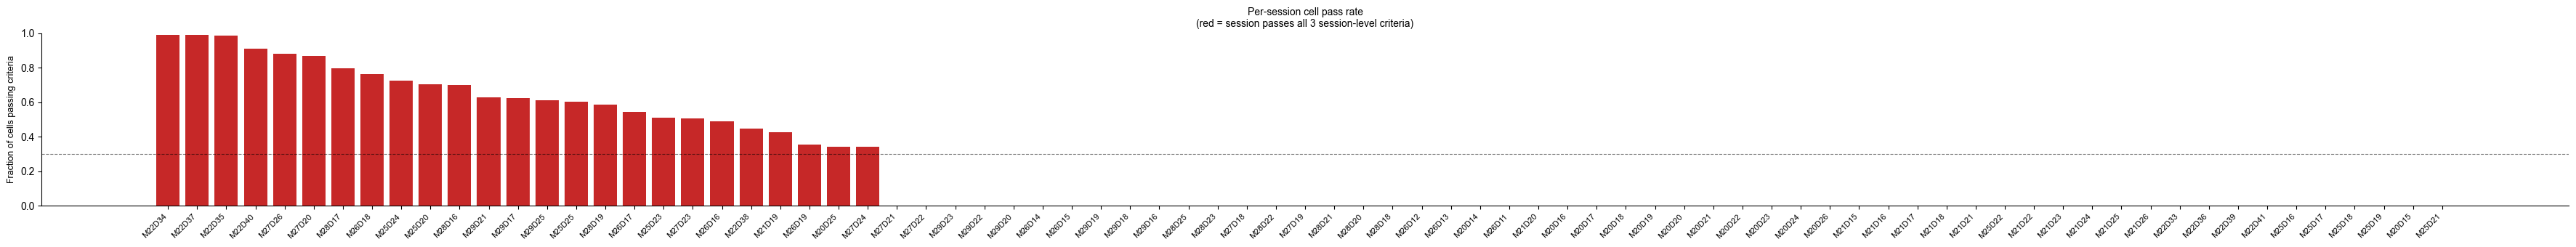


Preview:


,mouse,day,cluster_id,region,cell_corr,cell_agrees,lag1_autocorr,n_cells,agree_frac,var_expl,pc1_enrichment,pc1_dominance,session_passes,passes_criteria
1249,20,25,96,ENTm2,0.6316,True,0.8128,35,0.3429,0.227,7.9442,2.4951,True,True
1250,20,25,100,ENTm2,0.4388,True,0.7984,35,0.3429,0.227,7.9442,2.4951,True,True
1251,20,25,103,ENTm2,0.7209,True,0.8283,35,0.3429,0.227,7.9442,2.4951,True,True
1253,20,25,121,ENTm2,0.6872,True,0.7951,35,0.3429,0.227,7.9442,2.4951,True,True
1255,20,25,157,ENTm3,0.3759,True,0.7033,35,0.3429,0.227,7.9442,2.4951,True,True
1269,20,25,83,ENTm2,0.7001,True,0.8363,35,0.3429,0.227,7.9442,2.4951,True,True
1270,20,25,102,ENTm2,0.7444,True,0.7985,35,0.3429,0.227,7.9442,2.4951,True,True
1271,20,25,106,ENTm2,0.6408,True,0.8134,35,0.3429,0.227,7.9442,2.4951,True,True
1272,20,25,107,ENTm2,0.4214,True,0.7821,35,0.3429,0.227,7.9442,2.4951,True,True
1273,20,25,111,ENTm2,0.8166,True,0.8367,35,0.3429,0.227,7.9442,2.4951,True,True


In [16]:
%matplotlib inline
from IPython.display import display as _disp

if not cell_rows:
    print('No cell records — run cell-main first')
else:
    df_cells = pd.DataFrame(cell_rows)

    FLAGS_CSV = (Path('/Users/harryclark/Documents/spatial-manifolds/data/')
                 / 'task_anchoring_cell_flags.csv')
    df_cells.to_csv(FLAGS_CSV, index=False)
    print(f'Saved: {FLAGS_CSV}')
    print(f'Rows: {len(df_cells)}')

    n_sessions      = df_cells[['mouse','day']].drop_duplicates().shape[0]
    n_sess_pass     = df_cells[df_cells['session_passes']][['mouse','day']].drop_duplicates().shape[0]
    n_cells_total   = len(df_cells)
    n_cells_pass    = df_cells['passes_criteria'].sum()

    print(f'\nSessions:  {n_sess_pass}/{n_sessions} pass session-level criteria')
    print(f'Cells:     {n_cells_pass}/{n_cells_total} pass combined criteria  '
          f'({100*n_cells_pass/n_cells_total:.1f}%)')

    # Breakdown by region
    for reg in sorted(df_cells['region'].unique()):
        sub = df_cells[df_cells['region'] == reg]
        n_p = sub['passes_criteria'].sum()
        print(f'  {reg}: {n_p}/{len(sub)} ({100*n_p/len(sub):.1f}%)')

    # Quick bar: pass rate per session
    sess_summary = (df_cells.groupby(['mouse','day'])
                    .agg(n_cells=('cluster_id','count'),
                         n_pass=('passes_criteria','sum'),
                         session_passes=('session_passes','first'))
                    .reset_index())
    sess_summary['pass_rate'] = sess_summary['n_pass'] / sess_summary['n_cells']
    sess_summary = sess_summary.sort_values('pass_rate', ascending=False)

    fig_fl, ax_fl = plt.subplots(figsize=(max(5, len(sess_summary) * 0.45), 3.5))
    xlabels_fl = [f"M{int(r.mouse)}D{int(r.day)}" for _, r in sess_summary.iterrows()]
    colors_fl  = ['#c62828' if r.session_passes else '#90a4ae'
                  for _, r in sess_summary.iterrows()]
    ax_fl.bar(np.arange(len(sess_summary)), sess_summary['pass_rate'],
              color=colors_fl, edgecolor='none')
    ax_fl.axhline(0.3, color='k', lw=0.8, ls='--', alpha=0.5)
    ax_fl.set_xticks(np.arange(len(sess_summary)))
    ax_fl.set_xticklabels(xlabels_fl, rotation=45, ha='right', fontsize=8)
    ax_fl.set_ylabel('Fraction of cells passing criteria', fontsize=9)
    ax_fl.set_ylim(0, 1)
    ax_fl.set_title('Per-session cell pass rate\n(red = session passes all 3 session-level criteria)',
                    fontsize=10)
    ax_fl.spines['top'].set_visible(False); ax_fl.spines['right'].set_visible(False)
    fig_fl.tight_layout()
    _disp(fig_fl)
    plt.close(fig_fl)

    print('\nPreview:')
    _disp(df_cells[df_cells['passes_criteria']].head(10))

## Validation: streakiness of passing vs. failing cells

Cells that pass the inclusion criteria should show clear temporal persistence in
their anchoring state — long runs of consecutive anchored or non-anchored trials.
Cells that fail should look more like random noise.

**Metric: lag-k autocorrelation of the binary anchoring sequence.**
For a streaky cell, consecutive trials tend to share the same state, so the
autocorrelation at short lags is high and decays slowly.  The complement
`1 - ρ(lag=1)` is the **transition rate** — the probability that a cell switches
anchoring state between adjacent trials.  Noisy cells have a transition rate
near 0.5 (random coin flip); streaky cells have a transition rate near 0.

### Panels

- **Left**: Mean ± SEM autocorrelogram (lags 1–20 trials) for passing cells
  (green) vs. failing cells (grey).  Streaky cells should show sustained
  positive autocorrelation across many lags; noise should collapse to zero
  at lag 1.
- **Right**: Distribution of `1 - ρ(lag=1)` per cell for each group (violin +
  individual points).  A Mann-Whitney U test confirms whether the groups
  differ significantly.

Mann-Whitney U  pass vs fail  1-lag1_autocorr:  U=9261228  p=7.58e-09
Passing cells n=2149  median 1-rho=0.195
Failing cells n=7985  median 1-rho=0.214


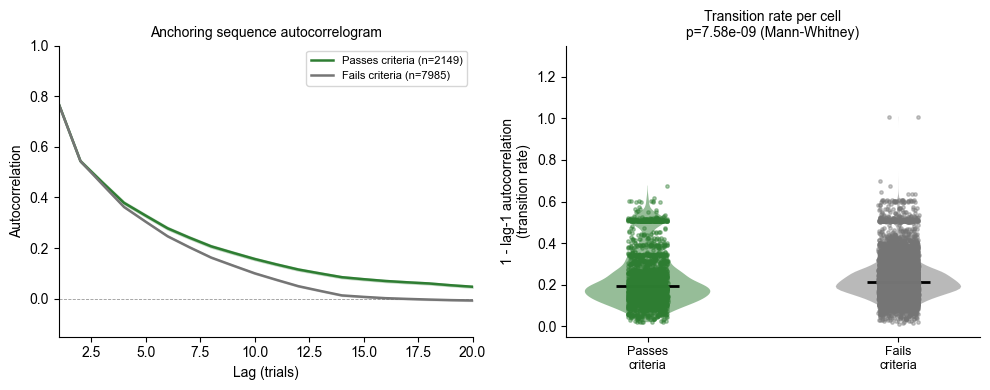

In [17]:
%matplotlib inline
from IPython.display import display as _disp
from scipy.stats import mannwhitneyu

if not acf_data:
    print('Run cell-main first')
else:
    MAX_LAG  = 20
    lags     = np.arange(1, MAX_LAG + 1)

    pass_acf = np.array([r['acf'][:MAX_LAG] for r in acf_data if r['passes_criteria']],
                        dtype=float)
    fail_acf = np.array([r['acf'][:MAX_LAG] for r in acf_data if not r['passes_criteria']],
                        dtype=float)

    def _mean_sem(mat):
        mean = np.nanmean(mat, axis=0)
        sem  = np.nanstd(mat, axis=0) / np.sqrt(np.sum(~np.isnan(mat), axis=0))
        return mean, sem

    pass_mean, pass_sem = _mean_sem(pass_acf)
    fail_mean, fail_sem = _mean_sem(fail_acf)

    # Lag-1 autocorr per cell for violin
    pass_lag1 = pass_acf[:, 0][~np.isnan(pass_acf[:, 0])]
    fail_lag1 = fail_acf[:, 0][~np.isnan(fail_acf[:, 0])]

    stat, pval = mannwhitneyu(pass_lag1, fail_lag1, alternative='greater')
    print(f'Mann-Whitney U  pass vs fail  1-lag1_autocorr:  U={stat:.0f}  p={pval:.2e}')
    print(f'Passing cells n={len(pass_lag1)}  median 1-rho={1-np.median(pass_lag1):.3f}')
    print(f'Failing cells n={len(fail_lag1)}  median 1-rho={1-np.median(fail_lag1):.3f}')

    fig_val, (ax_acf, ax_vio) = plt.subplots(1, 2, figsize=(10, 4))

    # --- Autocorrelogram ---
    ax_acf.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
    for mean, sem, color, label, n in [
        (pass_mean, pass_sem, '#2e7d32', f'Passes criteria (n={len(pass_lag1)})', len(pass_lag1)),
        (fail_mean, fail_sem, '#757575', f'Fails criteria (n={len(fail_lag1)})',  len(fail_lag1)),
    ]:
        ax_acf.fill_between(lags, mean - sem, mean + sem, alpha=0.25, color=color)
        ax_acf.plot(lags, mean, color=color, lw=1.8, label=label)
    ax_acf.set_xlabel('Lag (trials)', fontsize=10)
    ax_acf.set_ylabel('Autocorrelation', fontsize=10)
    ax_acf.set_title('Anchoring sequence autocorrelogram', fontsize=10)
    ax_acf.set_xlim(1, MAX_LAG); ax_acf.set_ylim(-0.15, 1.0)
    ax_acf.legend(fontsize=8)
    ax_acf.spines['top'].set_visible(False); ax_acf.spines['right'].set_visible(False)

    # --- Violin: 1 - lag-1 autocorr ---
    trans_pass = 1 - pass_lag1
    trans_fail = 1 - fail_lag1
    vdata  = [trans_pass, trans_fail]
    colors = ['#2e7d32', '#757575']
    parts  = ax_vio.violinplot(vdata, positions=[1, 2], showmedians=True, showextrema=False)
    for pc, col in zip(parts['bodies'], colors):
        pc.set_facecolor(col); pc.set_alpha(0.5)
    parts['cmedians'].set_color('k'); parts['cmedians'].set_linewidth(2)
    rng = np.random.default_rng(0)
    for xi, arr, col in zip([1, 2], vdata, colors):
        jitter = rng.uniform(-0.08, 0.08, len(arr))
        ax_vio.scatter(xi + jitter, arr, s=6, alpha=0.4, color=col, zorder=3)
    ax_vio.set_xticks([1, 2])
    ax_vio.set_xticklabels(['Passes\ncriteria', 'Fails\ncriteria'], fontsize=9)
    ax_vio.set_ylabel('1 - lag-1 autocorrelation\n(transition rate)', fontsize=10)
    ax_vio.set_title(f'Transition rate per cell\np={pval:.2e} (Mann-Whitney)', fontsize=10)
    ax_vio.set_ylim(-0.05, 1.35)
    ax_vio.spines['top'].set_visible(False); ax_vio.spines['right'].set_visible(False)

    fig_val.tight_layout()
    _disp(fig_val)
    plt.close(fig_val)